Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

import sys
import os

sys.path.append(os.path.abspath(".."))

from src.compositional_transforms import clr, alr
from src.variation_matrix import variation_matrix


Load data

In [2]:
df = pd.read_csv("../data/processed/synthetic_geochemistry_clean.csv")
elements = [c for c in df.columns if c not in ["cluster_true"]]

df.head(10)

,Br,Cl,F,SO4,Ca,Mg,Sr,Cu,Co,Pb,Zn,Li,Na,K,Mn,Fe,Ba,cluster_true
0,0.095899,0.062366,0.022015,0.127606,0.062787,0.084068,0.101009,0.016696,0.013143,0.018529,0.008178,0.073702,0.101234,0.049293,0.080354,0.039854,0.043268,A
1,0.099971,0.093327,0.017877,0.117157,0.060494,0.050880,0.050899,0.013455,0.025303,0.033002,0.016710,0.059443,0.140393,0.075276,0.055428,0.043988,0.046396,A
2,0.097458,0.112086,0.021785,0.102999,0.059963,0.030859,0.026210,0.009703,0.013486,0.033962,0.014224,0.067155,0.229360,0.091934,0.041578,0.027898,0.019340,A
3,0.131455,0.100846,0.023954,0.182852,0.073364,0.047819,0.016653,0.020484,0.014308,0.021735,0.033938,0.038828,0.117878,0.039912,0.039828,0.071948,0.024198,A
4,0.069935,0.084173,0.019400,0.114066,0.058589,0.046485,0.015482,0.008719,0.033469,0.017132,0.021410,0.097667,0.160111,0.092357,0.073442,0.056498,0.031067,A
5,0.078353,0.099664,0.033714,0.118878,0.065316,0.043945,0.019352,0.030324,0.032821,0.026388,0.011254,0.107708,0.111900,0.057874,0.056924,0.085164,0.020420,A
6,0.139627,0.136777,0.013133,0.050773,0.036093,0.075575,0.042134,0.009460,0.009850,0.015883,0.020120,0.075195,0.096866,0.081852,0.085998,0.085843,0.024821,A
7,0.104627,0.067142,0.011823,0.150891,0.038309,0.091525,0.049294,0.018152,0.023935,0.015690,0.009249,0.072828,0.175568,0.037389,0.016712,0.071969,0.044897,A
8,0.065775,0.109166,0.010385,0.147934,0.025342,0.056096,0.017875,0.012712,0.024498,0.013922,0.027306,0.131434,0.087283,0.070091,0.046787,0.090279,0.063114,A
9,0.074831,0.061395,0.021053,0.239808,0.127480,0.097977,0.046793,0.014006,0.008490,0.022728,0.011131,0.049308,0.087676,0.035773,0.031037,0.047629,0.022884,A


Apply clr (central log-ratio)

In [3]:
df_clr = clr(df[elements])
df_clr.head(10)

,Br,Cl,F,SO4,Ca,Mg,Sr,Cu,Co,Pb,Zn,Li,Na,K,Mn,Fe,Ba
0,0.746251,0.315967,-0.725338,1.031902,0.322700,0.614582,0.798161,-1.001871,-1.241130,-0.897711,-1.715558,0.482986,0.800385,0.080730,0.569394,-0.131824,-0.049627
1,0.729605,0.660838,-0.991739,0.888241,0.227267,0.054199,0.054580,-1.275910,-0.644361,-0.378698,-1.059244,0.209740,1.069177,0.445892,0.139806,-0.091344,-0.038048
2,0.871193,1.011035,-0.627001,0.926490,0.385496,-0.278802,-0.442086,-1.435748,-1.106555,-0.182974,-1.053325,0.498767,1.727061,0.812838,0.019348,-0.379677,-0.746062
3,1.090503,0.825440,-0.612017,1.420517,0.507270,0.079267,-0.975566,-0.768535,-1.127371,-0.709225,-0.263633,-0.129010,0.981496,-0.101476,-0.103580,0.487791,-0.601873
4,0.449769,0.635069,-0.832540,0.938980,0.272746,0.041319,-1.058140,-1.632335,-0.287189,-0.956847,-0.733949,0.783759,1.278069,0.727864,0.498698,0.236396,-0.361669
5,0.494237,0.734823,-0.349069,0.911110,0.312247,-0.084045,-0.904176,-0.455039,-0.375924,-0.594073,-1.446301,0.812440,0.850622,0.191283,0.174734,0.577595,-0.850466
6,1.190138,1.169518,-1.173684,0.178524,-0.162743,0.576285,-0.007984,-1.501796,-1.461380,-0.983592,-0.747133,0.571255,0.824497,0.656082,0.705484,0.703689,-0.537159
7,0.919244,0.475641,-1.261127,1.285397,-0.085471,0.785453,0.166632,-0.832373,-0.555837,-0.978169,-1.506652,0.556934,1.436865,-0.109775,-0.915043,0.545078,0.073202
8,0.413773,0.920402,-1.432053,1.224305,-0.540000,0.254607,-0.889033,-1.229885,-0.573879,-1.139003,-0.465361,1.106038,0.696690,0.477334,0.073137,0.730444,0.372485
9,0.613614,0.415713,-0.654597,1.778217,1.146336,0.883108,0.144109,-1.062135,-1.562715,-0.578045,-1.291860,0.196465,0.772026,-0.124441,-0.266437,0.161824,-0.571184


Apply alr (additive log-ratio) with Na as denominator <br>

P.S. Na was chosen to represent the salinity of the studied fluids (e.g., brines)

In [4]:
df_alr = alr(df[elements], denominator="Na")
df_alr.head(10)

,Br,Cl,F,SO4,Ca,Mg,Sr,Cu,Co,Pb,Zn,Li,Na,K,Mn,Fe,Ba
0,-0.054134,-0.484417,-1.525723,0.231517,-0.477685,-0.185803,-0.002224,-1.802256,-2.041514,-1.698096,-2.515942,-0.317398,0.0,-0.719655,-0.230991,-0.932209,-0.850011
1,-0.339573,-0.408340,-2.060917,-0.180937,-0.841910,-1.014979,-1.014598,-2.345088,-1.713539,-1.447875,-2.128421,-0.859437,0.0,-0.623285,-0.929371,-1.160522,-1.107225
2,-0.855868,-0.716026,-2.354062,-0.800571,-1.341565,-2.005863,-2.169147,-3.162809,-2.833616,-1.910035,-2.780386,-1.228294,0.0,-0.914223,-1.707713,-2.106738,-2.473123
3,0.109007,-0.156057,-1.593513,0.439021,-0.474226,-0.902230,-1.957062,-1.750031,-2.108867,-1.690721,-1.245130,-1.110506,0.0,-1.082972,-1.085077,-0.493705,-1.583369
4,-0.828300,-0.643000,-2.110609,-0.339089,-1.005323,-1.236750,-2.336209,-2.910404,-1.565258,-2.234916,-2.012018,-0.494310,0.0,-0.550205,-0.779371,-1.041673,-1.639738
5,-0.356385,-0.115799,-1.199691,0.060488,-0.538375,-0.934667,-1.754798,-1.305661,-1.226546,-1.444695,-2.296923,-0.038182,0.0,-0.659339,-0.675888,-0.273027,-1.701088
6,0.365641,0.345022,-1.998181,-0.645972,-0.987239,-0.248212,-0.832481,-2.326292,-2.285877,-1.808089,-1.571630,-0.253242,0.0,-0.168414,-0.119012,-0.120808,-1.361656
7,-0.517622,-0.961224,-2.697992,-0.151469,-1.522336,-0.651412,-1.270233,-2.269239,-1.992702,-2.415034,-2.943517,-0.879931,0.0,-1.546640,-2.351909,-0.891787,-1.363663
8,-0.282917,0.223712,-2.128743,0.527615,-1.236690,-0.442083,-1.585722,-1.926575,-1.270569,-1.835693,-1.162051,0.409348,0.0,-0.219356,-0.623553,0.033754,-0.324205
9,-0.158412,-0.356313,-1.426623,1.006191,0.374310,0.111082,-0.627917,-1.834161,-2.334741,-1.350071,-2.063886,-0.575561,0.0,-0.896467,-1.038463,-0.610202,-1.343210


Visualize the variation matrix<br>

The variation matrix shows the log-ratio variance between each pair of elements. Low values indicate proportionality; high values indicate independence.

In [5]:
V = variation_matrix(df[elements])
V

,Br,Cl,F,SO4,Ca,Mg,Sr,Cu,Co,Pb,Zn,Li,Na,K,Mn,Fe,Ba
Br,0.000000,0.315392,0.642358,0.386421,1.157990,1.357402,1.343920,3.384165,2.837360,3.415555,3.120162,0.581793,0.685199,0.762242,1.175836,1.277495,1.409155
Cl,0.315392,0.000000,0.583392,0.422213,1.114542,1.287851,1.238143,3.216101,2.683889,3.224223,2.924536,0.522335,0.616253,0.656253,1.082013,1.195445,1.304052
F,0.642358,0.583392,0.000000,0.645870,0.507036,0.545538,0.459722,1.545461,1.215687,1.543176,1.364737,0.287192,0.172611,0.190752,0.392793,0.439533,0.439557
SO4,0.386421,0.422213,0.645870,0.000000,1.149928,1.278333,1.276297,3.201071,2.658969,3.210590,2.940981,0.599181,0.662701,0.751127,1.128627,1.195174,1.314955
Ca,1.157990,1.114542,0.507036,1.149928,0.000000,0.799068,0.667167,1.437674,1.114587,1.439232,1.276467,0.628227,0.459339,0.491278,0.619346,0.612274,0.578894
Mg,1.357402,1.287851,0.545538,1.278333,0.799068,0.000000,0.604574,1.245777,0.960774,1.249528,1.140808,0.707715,0.527909,0.499874,0.575374,0.597036,0.538331
Sr,1.343920,1.238143,0.459722,1.276297,0.667167,0.604574,0.000000,1.069494,0.825556,1.074540,0.944093,0.638026,0.428760,0.421373,0.491725,0.472534,0.431058
Cu,3.384165,3.216101,1.545461,3.201071,1.437674,1.245777,1.069494,0.000000,0.350220,0.309479,0.343469,1.931533,1.415729,1.373394,1.166914,1.032335,0.832522
Co,2.837360,2.683889,1.215687,2.658969,1.114587,0.960774,0.825556,0.350220,0.000000,0.362113,0.371141,1.532375,1.091033,1.040231,0.891629,0.798592,0.609466
Pb,3.415555,3.224223,1.543176,3.210590,1.439232,1.249528,1.074540,0.309479,0.362113,0.000000,0.338612,1.902884,1.415231,1.391457,1.199081,1.062509,0.839884


Heatmap of the variation matrix

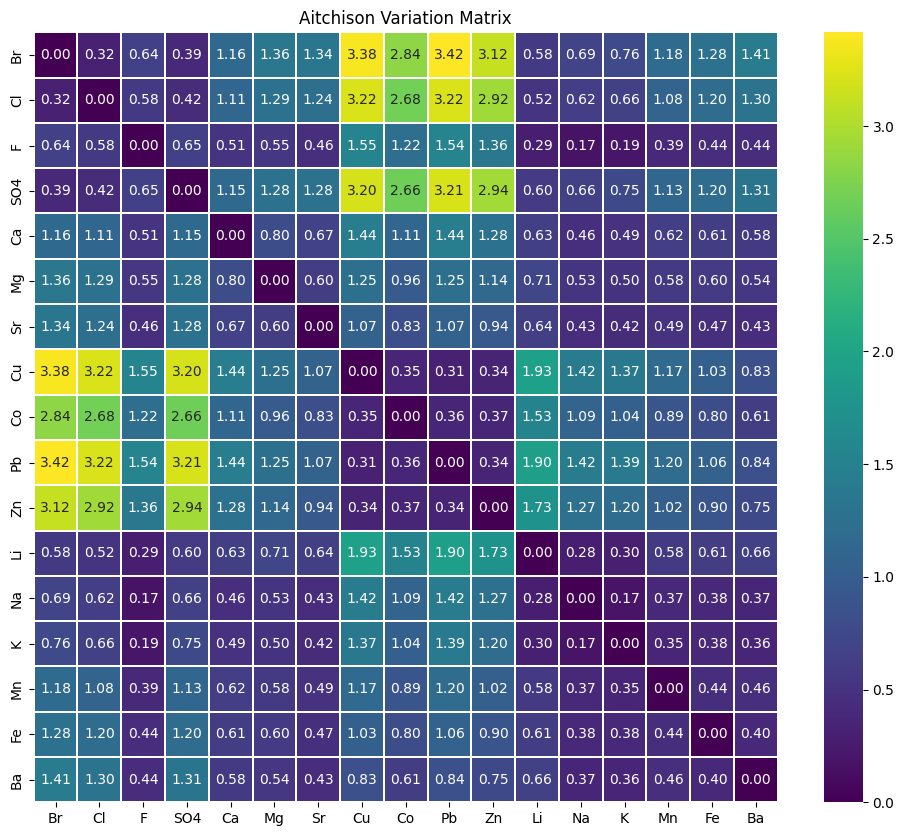

In [8]:
plt.figure(figsize=(12,10))
sns.heatmap(V, cmap="viridis", annot=True, fmt=".2f", linewidths=0.3)
plt.title("Aitchison Variation Matrix")
plt.show()